# Headers

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sys
import os
import io
from contextlib import redirect_stdout, redirect_stderr

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
    
parent_dir = os.path.join(current_dir, '..', '..')
sys.path.insert(0, parent_dir)
    
    
from analysis_scripts.config import CFG
from analysis_scripts.fit_scripts import fit_distr_double_gauss
from analysis_scripts.selection_scripts import auto_preselection
from analysis_scripts.draw_scripts import draw_feature_distribution


CFG.seed_all(CFG.seed)
sns.set_theme(style='ticks')

CUDA available: False
Use CPU, 
Number of CPUs: 12


# Prepare Data

**Same as in data_explore.ipynb**

In [2]:
data_oc_df_1 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_1_new.csv')
data_mb_df_1 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_1_new.csv')

data_oc_df_2 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_signal_2_new.csv')
data_mb_df_2 = pd.read_csv('/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/Data/analysed_background_2_new.csv')

In [3]:
raw_df_list = []

for data_oc_df, data_mb_df in zip([data_oc_df_2, data_oc_df_1], [data_mb_df_2, data_mb_df_1]):
    
    data_oc_df = data_oc_df.drop(['n_event'], axis=1)

    mass_mask = (data_oc_df['mass_Lc'] > CFG.mass_interval[0]) \
                & ( data_oc_df['mass_Lc'] < CFG.mass_interval[1]) \
                & (data_oc_df['true_decay'] == 1)
    
    data_oc_df = data_oc_df[mass_mask]
    data_oc_df['tag'] = 'Sig'

    data_mb_df = data_mb_df.drop(['n_event'], axis=1)

    mass_mask = (data_mb_df['mass_Lc'] > CFG.mass_interval[0]) & ( data_mb_df['mass_Lc'] < CFG.mass_interval[1])

    data_mb_df = data_mb_df[mass_mask]
    data_mb_df['tag'] = 'Bg'

    raw_df = pd.concat([data_oc_df, data_mb_df], axis=0).reset_index(drop=True)
    
    raw_df = raw_df.copy()
    
    raw_df_list.append(raw_df)

In [4]:
proc_df_list = []

selection_mask_train = None

for raw_df in raw_df_list:
    
    proc_df = raw_df.copy()

    # min_tracks_after_re_fit = 7
    # proc_df = proc_df[proc_df['kf_pv_size_after_re_fit'] > min_tracks_after_re_fit]

    features_to_select = [
        # Default features
        # 'P_p', 'P_pip', 'P_K',
        # 'eta_p', 'eta_pip', 'eta_K', 
        # 'P_Lc', 'Pt_Lc', 'eta_Lc',
        # 'Pt_p', 'Pt_K', 'Pt_pip',
        'lengthXY_Lc', 'dlengthXY_Lc', 'ctau_Lc', 
        'chi2_Lc_PV_xy', 'dist_Lc_PV_xy', 'dist_Lc_PV_xy_custom',
        'chi2_p_PV_xy', 'dist_p_PV_xy', 'dist_p_PV_xy_custom',
        'chi2_K_PV_xy', 'dist_K_PV_xy', 'dist_K_PV_xy_custom', 
        'chi2_pip_PV_xy','dist_pip_PV_xy', 'dist_pip_PV_xy_custom', 
        'chi2_p_Lc_xy','dist_p_Lc_xy', 'dist_p_Lc_xy_custom',
        'chi2_K_Lc_xy', 'dist_K_Lc_xy', 'dist_K_Lc_xy_custom',
        'chi2_pip_Lc_xy', 'dist_pip_Lc_xy', 'dist_pip_Lc_xy_custom',
        'chi2_K_pip_xy', 'dist_K_pip_xy','dist_K_pip_xy_custom',
        'chi2_p_K_xy', 'dist_p_K_xy', 'dist_p_K_xy_custom',
        'chi2_p_pip_xy', 'dist_p_pip_xy', 'dist_p_pip_xy_custom',
        'cosAngle_momentum_Lc_sum_momentum_xy', 'chi2_Lc', 'xF',
        # 'cosAngle_r_Lc_momentum_Lc_xy_left',
        # 'cosAngle_r_Lc_momentum_Lc_xy_right',
        # 'cosAngle_r_Lc_sum_momentum_xy_left',
        # 'cosAngle_r_Lc_sum_momentum_xy_right',
    ]

    quantile_dict = {}

    selection_df, mask = auto_preselection(
        df=proc_df,
        features=features_to_select,
        safety_interval=0.95,
        indent=2,
        quantile_left=1e-3,
        quantile_right=1 - 1e-3,
        recursive=True,
        quantile_dict=quantile_dict,
    )

    if selection_mask_train is None:
        proc_df = proc_df.query(mask).reset_index(drop=True)
        selection_mask_train = mask
    else:
        proc_df = proc_df.query(selection_mask_train).reset_index(drop=True)

    proc_df_copy = proc_df.copy()

    sig_eff_presel = proc_df.loc[proc_df['tag'] == 'Sig', 'mass_Lc'].count() / raw_df.loc[raw_df['tag'] == 'Sig', 'mass_Lc'].count()
    bg_eff_presel = proc_df.loc[proc_df['tag'] == 'Bg', 'mass_Lc'].count() / raw_df.loc[raw_df['tag'] == 'Bg', 'mass_Lc'].count()

    print(f'Signal efficiency: {sig_eff_presel}')
    print(f'Background Suppression: {bg_eff_presel}')
    
    proc_df_list.append(proc_df)

Signal efficiency: 0.9471311915238197
Background Suppression: 0.6236141088465027
Signal efficiency: 0.9471810669404919
Background Suppression: 0.6200400630780377


In [5]:
proc_df = proc_df_list[1]

del proc_df_list[0]
del data_oc_df_1
del data_mb_df_1
del data_oc_df_2
del data_mb_df_2
del data_oc_df
del data_mb_df
del raw_df_list
del raw_df
del proc_df_copy

In [6]:
proc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387814 entries, 0 to 387813
Data columns (total 75 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   id                                    387814 non-null  int64  
 1   mass_Lc                               387814 non-null  float64
 2   P_p                                   387814 non-null  float64
 3   P_pip                                 387814 non-null  float64
 4   P_K                                   387814 non-null  float64
 5   P_Lc                                  387814 non-null  float64
 6   eta_p                                 387814 non-null  float64
 7   eta_pip                               387814 non-null  float64
 8   eta_K                                 387814 non-null  float64
 9   eta_Lc                                387814 non-null  float64
 10  Pt_Lc                                 387814 non-null  float64
 11  

In [7]:
# Remove duplicated PVs

proc_df = proc_df.drop_duplicates(subset=('id'))
proc_df = proc_df[[
    'tag', 'PV_diff_ES_x', 'PV_diff_ES_y', 'PV_diff_ES_z', 'kf_pv_size_before_re_fit', 'kf_pv_size_after_re_fit',
    'lengthXY_Lc', 'dlengthXY_Lc', 'ctau_Lc'
]]
proc_df = proc_df.reset_index(drop=True)
proc_df['l_over_dl_XY'] = proc_df['lengthXY_Lc'] / proc_df['dlengthXY_Lc']


proc_df.head()

,tag,PV_diff_ES_x,PV_diff_ES_y,PV_diff_ES_z,kf_pv_size_before_re_fit,kf_pv_size_after_re_fit,lengthXY_Lc,dlengthXY_Lc,ctau_Lc,l_over_dl_XY
0,Sig,0.001009,-0.004212,-0.005143,13,13,-0.012243,0.016012,-0.014816,-0.764614
1,Sig,-0.004101,0.007971,0.011696,7,7,-0.000059,0.012511,-0.000051,-0.004704
2,Sig,0.002510,0.003912,-0.000190,13,13,0.007578,0.012703,0.007840,0.596550
3,Sig,-0.001860,0.002775,-0.001198,10,10,0.015073,0.009496,0.014640,1.587193
4,Sig,0.006621,0.000625,0.009463,4,4,0.003070,0.009748,0.003378,0.314952


# PV resolution

### x-projection (no kf_pv_size_after_re_fit restriction)

Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_method='Powell'
Optimization result:
Success: True
Message: Optimization terminated successfully.
Number of iterations: 27
Final objective value: 92.317130
Chi-squared: 92.32
Reduced chi-squared: 2.797
---------------------------------------------

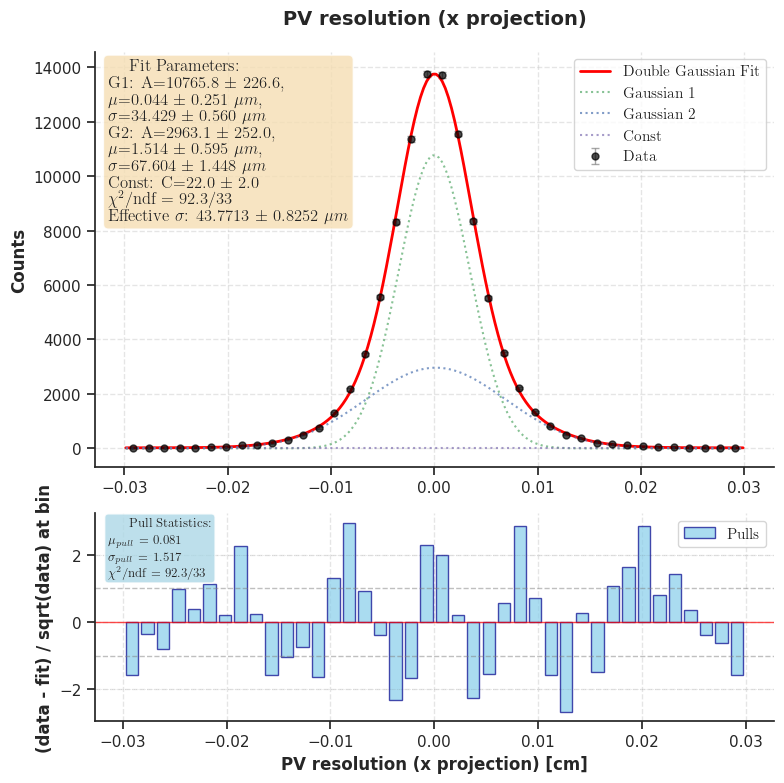

In [8]:
distr_name = 'PV_diff_ES_x'
distr = proc_df.loc[proc_df['tag'] == 'Sig', distr_name]
sig_PV_df_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=sig_PV_df_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=sig_PV_df_sel,
    title='PV resolution (x projection)',
    x_label='PV resolution (x projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/re_fit_setup_{distr_name}_no_sel.pdf', bbox_inches='tight')

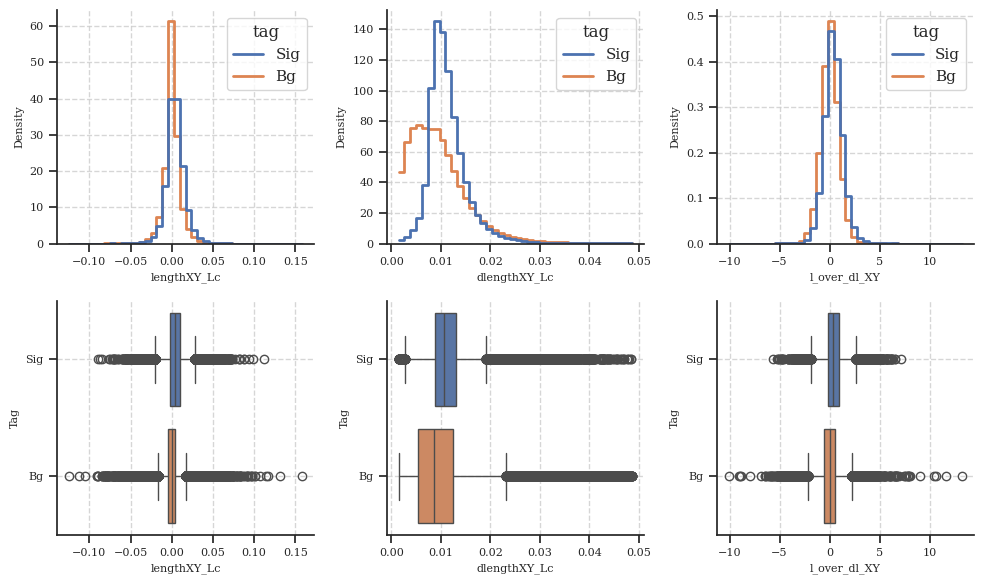

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['lengthXY_Lc', 'dlengthXY_Lc', 'l_over_dl_XY']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=proc_df,
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()
plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/re_fit_setup_length_no_sel.pdf', bbox_inches='tight')
plt.show()

### x-projection (with kf_pv_size_after_re_fit restriction)

In [10]:
min_tracks_after_re_fit = 7

count_after = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] > min_tracks_after_re_fit) & (proc_df['tag'] == 'Sig'), 'kf_pv_size_after_re_fit'].count()
count_before = proc_df.loc[(proc_df['tag'] == 'Sig'), 'kf_pv_size_before_re_fit'].count()
ratio = count_after / count_before
print(f'Efficiency of signal events after min_tracks_after_re_fit cut: {ratio}')

Efficiency of signal events after min_tracks_after_re_fit cut: 0.7759514320523675


Method: Nelder-Mead
Method: Powell
****************************************************************************************************
New best method: Powell, success: True
****************************************************************************************************
Method: CG
Method: BFGS
Method: Newton-CG
Method: L-BFGS-B
Method: TNC
Method: COBYLA
Method: COBYQA
Method: SLSQP
Skip method: SLSQP
Method: trust-constr
Method: dogleg
Method: trust-ncg
Method: trust-exact
Method: trust-krylov
********************************************************************************
********************************************************************************
********************************************************************************
best_method='Powell'
Optimization result:
Success: True
Message: Optimization terminated successfully.
Number of iterations: 27
Final objective value: 58.356897
Chi-squared: 58.36
Reduced chi-squared: 1.768
---------------------------------------------

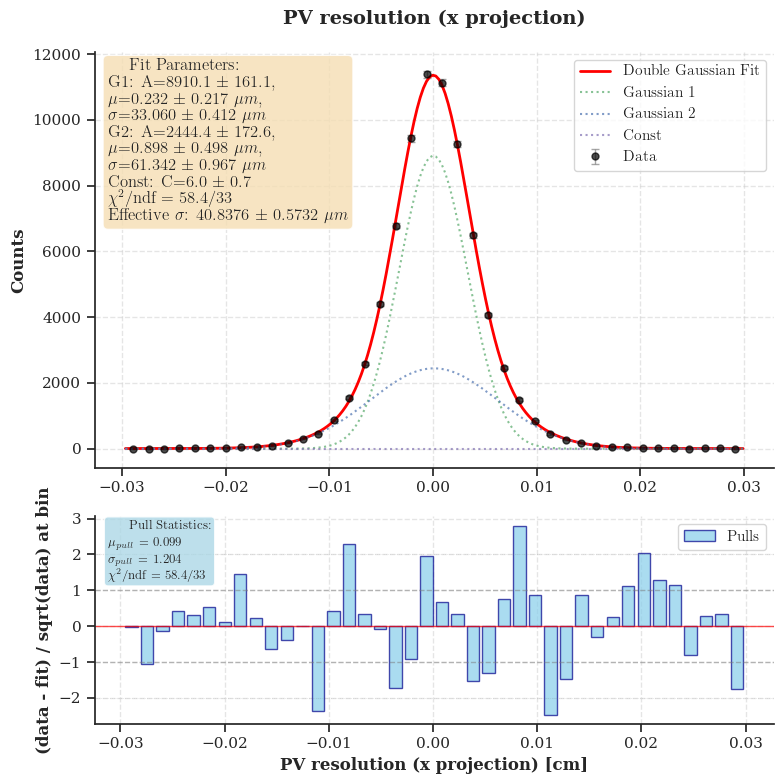

In [11]:
distr_name = 'PV_diff_ES_x'

distr = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] > min_tracks_after_re_fit) & (proc_df['tag'] == 'Sig'), distr_name]
sig_PV_df_sel = distr[abs(distr) < 0.03].copy()

methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr', 'dogleg',
           'trust-ncg', 'trust-exact', 'trust-krylov']

min_loss = 1e6
best_method = None

for method in methods:

    print(f'Method: {method}')

    if method in ('SLSQP'):
        print(f'Skip method: {method}')
        continue

    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        try:
            fit_res = fit_distr_double_gauss(
                distr=sig_PV_df_sel,
                title=distr_name,
                x_label=distr_name + ' [cm]',
                optimize_method=method,
                plot=False,
                bins=40,
                max_iter=1000,
                scaler=1e4,
                unit_name='$\\mu m$'
            )
        except:
            print(f'Skip method: {method}')
            continue
    
    result = fit_res['result']
    
    if result['success'] and result['fun'] < min_loss:
        print('*'*100)
        print(f'New best method: {method}, success: {result['success']}')
        print('*'*100)
        best_method = method
        min_loss = result['fun']
    
print('*' * 80)
print('*' * 80)
print('*' * 80)
print(f'{best_method=}')

if best_method is None:
    raise ValueError('No successful fit')

result = fit_distr_double_gauss(
    distr=sig_PV_df_sel,
    title='PV resolution (x projection)',
    x_label='PV resolution (x projection) [cm]',
    optimize_method=best_method,
    plot=True,
    bins=40,
    max_iter=1000,
    scaler=1e4,
    unit_name='$\\mu m$'
)

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/re_fit_setup_{distr_name}_sel.pdf', bbox_inches='tight')
plt.show()

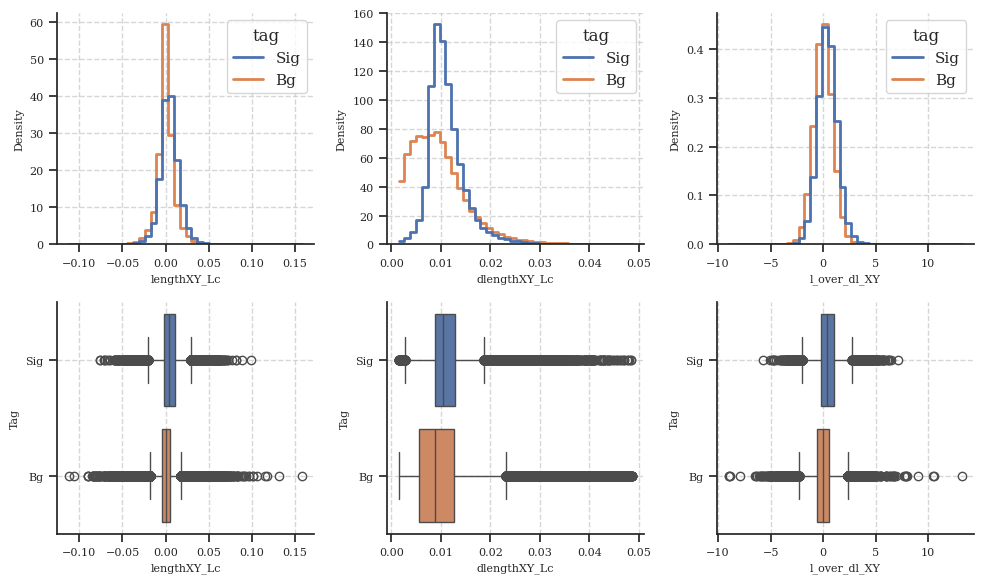

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

cols = ['lengthXY_Lc', 'dlengthXY_Lc', 'l_over_dl_XY']

for idx, col in enumerate(cols):
    draw_feature_distribution(
        df=proc_df.loc[proc_df['kf_pv_size_after_re_fit'] > min_tracks_after_re_fit],
        distr_name=col,
        axes=[axes[0][idx], axes[1][idx]],
        tag=None,
        hue='tag',
        bins=40,
        norma=True,
        cut_point=None,
        select_direction=None
    )

plt.tight_layout()
plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/re_fit_setup_length_sel.pdf', bbox_inches='tight')
plt.show()

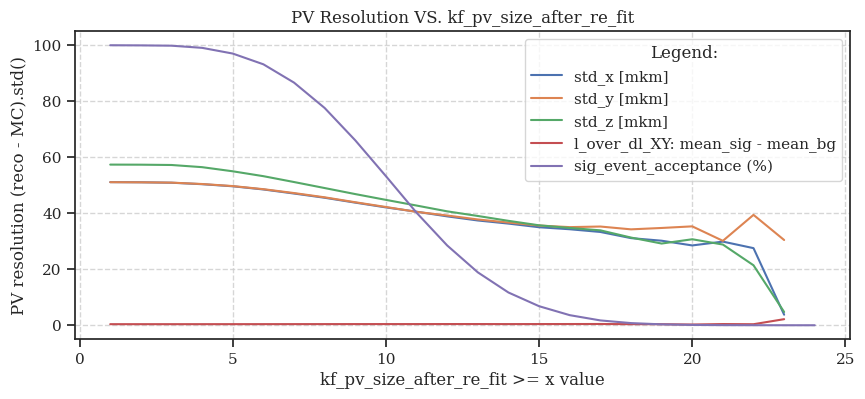

In [26]:
res_x = []
res_y = []
res_z = []
mean_diff_list = []
sig_event_acceptance_list = []

kf_pv_size_after_re_fit_list = np.sort(proc_df.kf_pv_size_after_re_fit.unique())

for cut in kf_pv_size_after_re_fit_list:

    PV_diff_x = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] >= cut) & (proc_df['tag'] == 'Sig'), 'PV_diff_ES_x']
    PV_diff_y = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] >= cut) & (proc_df['tag'] == 'Sig'), 'PV_diff_ES_y']
    PV_diff_z = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] >= cut) & (proc_df['tag'] == 'Sig'), 'PV_diff_ES_z']

    res_x_val = PV_diff_x[abs(PV_diff_x) < 0.03].std() * 1e4
    res_y_val = PV_diff_y[abs(PV_diff_y) < 0.03].std() * 1e4
    res_z_val = PV_diff_z[abs(PV_diff_z) < 0.03].std() * 1e4

    res_x.append(res_x_val)
    res_y.append(res_y_val)
    res_z.append(res_z_val)

    mean_diff = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] >= cut) & (proc_df['tag'] == 'Sig'), 'l_over_dl_XY'].mean() - \
                proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] >= cut) & (proc_df['tag'] == 'Bg'), 'l_over_dl_XY'].mean()
    mean_diff_list.append(mean_diff)

    sig_acceptance = proc_df.loc[(proc_df['kf_pv_size_after_re_fit'] >= cut) & (proc_df.tag == 'Sig'), 'PV_diff_ES_x'].count() / \
                    proc_df.loc[(proc_df.tag == 'Sig'), 'PV_diff_ES_x'].count()
    sig_event_acceptance_list.append(sig_acceptance * 100)
    
res_x = np.array(res_x)
res_y = np.array(res_y)
res_z = np.array(res_z)
mean_diff_list = np.array(mean_diff_list)
sig_event_acceptance_list = np.array(sig_event_acceptance_list)


res_df = pd.DataFrame({
    'cut': kf_pv_size_after_re_fit_list,
    'std_x [mkm]': res_x,
    'std_y [mkm]': res_y,
    'std_z [mkm]': res_z,
    'l_over_dl_XY: mean_sig - mean_bg': mean_diff_list,
    'sig_event_acceptance (%)': sig_event_acceptance_list
})

res_df_melted = res_df.melt(
    id_vars=['cut'], 
    value_vars=['std_x [mkm]', 'std_y [mkm]', 'std_z [mkm]', 'l_over_dl_XY: mean_sig - mean_bg', 'sig_event_acceptance (%)'],
    var_name='col_type',
    value_name='col_value'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=res_df_melted,
    x='cut',
    y='col_value',
    hue='col_type',
    ax=ax
)

ax.set_title("PV Resolution VS. kf_pv_size_after_re_fit")
ax.set_xlabel('kf_pv_size_after_re_fit >= x value')
ax.set_ylabel('PV resolution (reco - MC).std()')
ax.grid(True, linestyle='--', alpha=0.8)
ax.legend(title='Legend:')

plt.savefig(f'/home/ome123/Рабочий стол/SPD/SPD_Lc_pKpi_27/plots/kf_pv_size_after_re_fit_check.pdf', bbox_inches='tight')
plt.show()

# Results

* Based on the Lc length distribution constraints applied to the kf_pv_size_after_re_fit parameter, no significant improvement in decay length resolution is observed.

* Don't use kf_pv_size_after_re_fit in main analysis.
